# 线性回归 · 从零开始实现（PyTorch）

> 📌 **出处**：李沐《动手学深度学习 V2》第 3 章「线性回归的从零开始实现」
> 🎯 **目标**：不用框架的高级 API，只用 `torch.Tensor` 和自动求导，手动实现「**模型 → 损失 → 优化**」三步曲，把线性回归完整跑起来。

## 学完能掌握什么
1. 用 PyTorch 生成**合成数据**（带噪声的线性关系）；
2. 手写**小批量随机梯度下降（minibatch SGD）**；
3. 把「模型、损失、优化」拆成三个独立函数，拼成**训练循环**。

> 💡 这一节和「简洁实现」是同一件事的两种写法：这里把每个零件**亲手造**，简洁实现里用 `torch.nn` / `torch.optim` **一行代替**。


In [1]:
# ==================== 环境准备 ====================
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

蓝 = '#2b7bba'; 橙 = '#e69f00'; 灰 = '#999999'; 红 = '#d62728'; 绿 = '#2ca02c'; 紫 = '#9467bd'
np.random.seed(0); torch.manual_seed(0)

print("✓ 环境就绪：torch", torch.__version__)


✓ 环境就绪：torch 2.14.0+cpu


## 1. 生成合成数据：真实关系 y = Xw + b + 噪声

真实世界里我们**不知道**数据背后的规律。为了检验「机器学到的参数准不准」，我们先**自己造一批已知规律的数据**：真实权重 `w=[2, -3.4]`、真实偏置 `b=4.2`，再加一点高斯噪声。

> 🔑 这样做的意义：训练完拿「学到的 `w`/`b`」和「真实的 `w`/`b`」对比，一眼看出算法对不对。


In [2]:
# ---- 生成合成数据：y = X·w + b + 噪声 ----
def synthetic_data(w, b, num_examples):
    '''按 y = X·w + b + 噪声 生成 num_examples 条样本。X 服从标准正态，噪声也是小方差正态。'''
    X = torch.normal(0, 1, (num_examples, len(w)))         # 特征：num_examples 行、len(w) 列  （torch.normal是生成符合正太分布的随机特征量）
    y = torch.matmul(X, w) + b                               # 干净的线性关系  （matmul是torch的矩阵乘法公式）
    y += torch.normal(0, 0.01, y.shape)                     # 加一点高斯噪声（方差 0.01）
    return X, y.reshape((-1, 1))                            # y 变成列向量

真实w = torch.tensor([2.0, -3.4])   # 真实的权重（我们假装不知道）
真实b = 4.2                          # 真实的偏置
features, labels = synthetic_data(真实w, 真实b, 1000)

print("特征 X 形状：", tuple(features.shape))   # 1000 条样本，每条 2 个特征
print("标签 y 形状：", tuple(labels.shape))     # 1000 行 1 列
print("前 3 条样本：")
print("  X[0:3] =", features[0:3])
print("  y[0:3] =", labels[0:3].flatten())


特征 X 形状： (1000, 2)
标签 y 形状： (1000, 1)
前 3 条样本：
  X[0:3] = tensor([[-1.1258, -1.1524],
        [-0.2506, -0.4339],
        [ 0.8487,  0.6920]])
  y[0:3] = tensor([5.8655, 5.1871, 3.5518])


## 2. 读取小批量：每次喂一小撮数据

梯度下降可以「每次用全部数据」（BGD），但数据大时太慢。更常用的是**小批量随机梯度下降（minibatch SGD）**：每步随机抽 `batch_size` 条样本算梯度。

这里手写一个 `data_iter`，它做了两件事：**随机打乱** → **按 batch 切块**，用 `yield` 一个 batch 一个 batch 地吐数据。


In [3]:
# ---- 手写数据迭代器：随机打乱 → 按 batch 切块 ----
import random

def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)                                  # ① 随机打乱下标
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices] # ② 吐出一个 batch

batch_size = 10
print("一个 batch 的 X 形状：", tuple(next(data_iter(batch_size, features, labels))[0].shape))


一个 batch 的 X 形状： (10, 2)


## 3. 三步曲：模型、损失、优化（全部手写）

- **模型**：`linreg(X, w, b) = X @ w + b`，`w`/`b` 是待学参数（`requires_grad=True`）；
- **损失**：平方损失 `(y_hat - y)² / 2`（除以 2 让求导后更简洁）；
- **优化**：小批量 SGD，每个参数沿负梯度方向走 `lr` 步，更新完**梯度要清零**（否则会累加）。


In [4]:
# ---- 定义模型、损失、优化 ----
# ① 初始化参数（要 requires_grad=True，才能自动求梯度）
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def linreg(X, w, b):
    '''线性回归模型：y_hat = X @ w + b'''
    return torch.matmul(X, w) + b

def squared_loss(y_hat, y):
    '''平方损失：均方误差 MSE 的一半，即 (y_hat - y)² / 2'''
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

def sgd(params, lr, batch_size):
    '''小批量随机梯度下降：param -= lr * grad / batch_size，更新后清零梯度'''
    with torch.no_grad():                 # 更新参数时不算梯度
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()            # 🔑 梯度清零，防止累加


## 4. 训练循环：把三步曲串起来跑 3 轮

每一轮（epoch）遍历一遍所有 batch，每个 batch 做四件事：**前向 → 反向求梯度 → 更新参数**。训练完打印学到的参数，和真实值对比。


In [5]:
# ---- 训练：前向 → 反向 → 更新，跑 3 轮 ----
lr = 0.03            # 学习率
num_epochs = 3       # 轮数（扫全量数据 3 遍）
net = linreg         # 模型
loss = squared_loss  # 损失

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)   # ① 前向：算一个小批量的损失
        l.sum().backward()          # ② 反向：自动求梯度（存到 w.grad / b.grad）
        sgd([w, b], lr, batch_size) # ③ 更新参数
    # 每轮结束，用全量数据算一次总损失，看有没有在下降
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f"epoch {epoch + 1}, loss {float(train_l.mean()):.6f}")

print()
print("学到的 w =", w.detach().flatten().numpy(), "（真实 [2.0, -3.4]）")
print("学到的 b =", b.item(), "（真实 4.2）")


epoch 1, loss 0.039164
epoch 2, loss 0.000138
epoch 3, loss 0.000047

学到的 w = [ 2.0003226 -3.399247 ] （真实 [2.0, -3.4]）
学到的 b = 4.199299335479736 （真实 4.2）


## 5. 观察结果：损失一路下降、参数逼近真实值

画两张图：左边看**损失随 epoch 下降**，右边看**学到的 `w` 是否逼近真实 `w`**。3 轮下来参数已经相当接近，说明从零实现的小批量 SGD 确实有效。


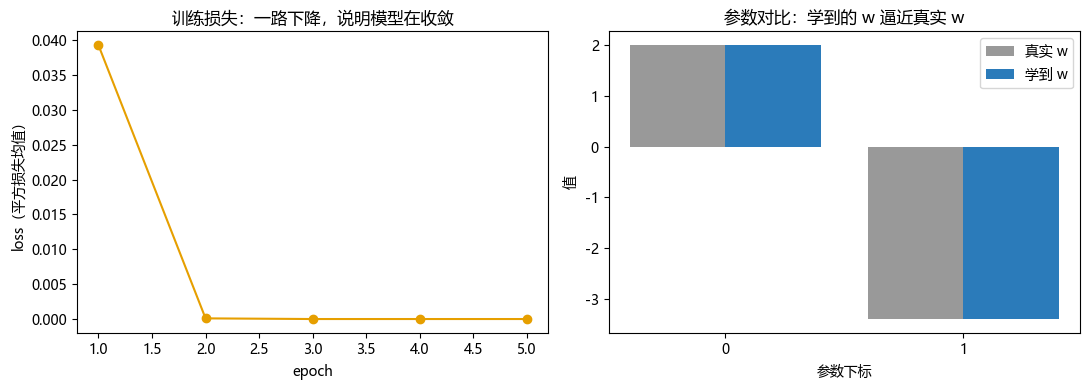

真实 b = 4.2，学到 b = 4.200


In [6]:
# ---- 可视化：损失曲线 + 参数对比 ----
# 重新跑一遍并记录每轮的损失（代码同上，只是把 loss 存下来画图）
w2 = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)
loss_history = []
for epoch in range(5):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w2, b2), y)
        l.sum().backward()
        sgd([w2, b2], lr, batch_size)
    with torch.no_grad():
        loss_history.append(float(loss(net(features, w2, b2), labels).mean()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 左：损失下降曲线
axes[0].plot(range(1, len(loss_history) + 1), loss_history, marker='o', color=橙)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss（平方损失均值）')
axes[0].set_title('训练损失：一路下降，说明模型在收敛')

# 右：学到的 w vs 真实 w
import numpy as np
学到的w = w2.detach().flatten().numpy()
真实w_np = 真实w.numpy()
x_pos = np.arange(len(真实w_np))
axes[1].bar(x_pos - 0.2, 真实w_np, width=0.4, label='真实 w', color=灰)
axes[1].bar(x_pos + 0.2, 学到的w, width=0.4, label='学到 w', color=蓝)
axes[1].set_xticks(x_pos); axes[1].set_xlabel('参数下标'); axes[1].set_ylabel('值')
axes[1].set_title('参数对比：学到的 w 逼近真实 w'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f"真实 b = {真实b}，学到 b = {b2.item():.3f}")
